# LOB Data Extraction and Cleaning Pipeline

## Dataset Sufficiency Check

Based on the dataset description and local files, there is enough information to build extraction and cleaning for model training:
- File naming provides split, auction flag, normalization type, and fold.
- Each file provides 149 rows where rows 1-144 are features and rows 145-149 are labels.
- Label values are expected in {1, 2, 3}.

## Notebook Sections
This notebook is organized into coherent sections:
1. Configuration, imports, and paper-based feature schema (`u1`-`u9`)
2. File discovery and metadata parsing
3. Raw file extraction into a tabular DataFrame
4. Data cleaning for direct model training
5. Final train/test model-ready matrices
6. Feature schema sanity checks
7. PyTorch logistic regression baseline

## 1) Setting Up

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("Data")
EXPECTED_FEATURE_ROWS = 144
EXPECTED_LABEL_ROWS = 5
EXPECTED_TOTAL_ROWS = EXPECTED_FEATURE_ROWS + EXPECTED_LABEL_ROWS


def build_paper_feature_names(n_levels: int = 10) -> list[str]:
    names: list[str] = []

    for i in range(1, n_levels + 1):
        names.extend([
            f"u1_ask_price_l{i}",
            f"u1_ask_volume_l{i}",
            f"u1_bid_price_l{i}",
            f"u1_bid_volume_l{i}",
        ])

    for i in range(1, n_levels + 1):
        names.extend([f"u2_spread_l{i}", f"u2_midprice_l{i}"])

    names.extend(["u3_ask_price_range_l10_l1", "u3_bid_price_range_l1_l10"])
    for i in range(1, n_levels):
        names.append(f"u3_abs_ask_price_diff_l{i+1}_l{i}")
    for i in range(1, n_levels):
        names.append(f"u3_abs_bid_price_diff_l{i+1}_l{i}")

    names.extend([
        "u4_mean_ask_price",
        "u4_mean_bid_price",
        "u4_mean_ask_volume",
        "u4_mean_bid_volume",
    ])

    names.extend(["u5_sum_spread", "u5_sum_volume_imbalance"])

    for i in range(1, n_levels + 1):
        names.extend([
            f"u6_dask_price_dt_l{i}",
            f"u6_dbid_price_dt_l{i}",
            f"u6_dask_volume_dt_l{i}",
            f"u6_dbid_volume_dt_l{i}",
        ])

    event_types = [
        "trade",
        "order",
        "cancellation",
        "deletion",
        "exec_visible",
        "exec_hidden",
    ]
    names.extend([f"u7_intensity_{event}" for event in event_types])
    names.extend([f"u8_rel_intensity_gt_long_{event}" for event in event_types])
    names.extend([f"u9_dintensity_dt_{event}" for event in event_types])

    if len(names) != EXPECTED_FEATURE_ROWS:
        raise ValueError(
            f"Paper feature schema must have {EXPECTED_FEATURE_ROWS} features, got {len(names)}"
        )

    return names


FEATURE_COLS = build_paper_feature_names(n_levels=10)
LABEL_COLS = [f"label_{i}" for i in range(1, EXPECTED_LABEL_ROWS + 1)]
META_COLS = ["file_name", "split", "auction", "normalization", "fold"]

print(f"Data directory exists: {DATA_DIR.exists()} -> {DATA_DIR.resolve()}")
print(f"Feature columns configured from paper schema: {len(FEATURE_COLS)}")

Data directory exists: True -> C:\Users\prane\Work\Coding\Projects\LOBForecasting\Data
Feature columns configured from paper schema: 144


## 2) File Discovery + Metadata Parsing

We parse file names of the form:
- `Train_Dst_NoAuction_DecPre_CF_7.txt`
- `Test_Dst_NoAuction_DecPre_CF_8.txt`

Parsed metadata fields:
- `split`: train/test
- `auction`: with_auction/no_auction
- `normalization`: zscore/minmax/decpre (or raw token if new)
- `fold`: cross-validation fold integer

In [2]:
FILE_PATTERN = re.compile(
    r"^(Train|Test)_Dst_(NoAuction|Auction)_([A-Za-z0-9]+)_CF_(\d+)\.txt$",
    re.IGNORECASE,
)


def parse_file_metadata(file_path: Path) -> dict:
    match = FILE_PATTERN.match(file_path.name)
    if not match:
        raise ValueError(
            f"Unexpected filename format: {file_path.name}. "
            "Expected e.g. Train_Dst_NoAuction_DecPre_CF_7.txt"
        )

    split_raw, auction_raw, norm_raw, fold_raw = match.groups()

    split = split_raw.lower()
    auction = "no_auction" if auction_raw.lower() == "noauction" else "with_auction"

    normalization_lookup = {
        "zscore": "zscore",
        "minmax": "minmax",
        "decpre": "decpre",
    }
    normalization = normalization_lookup.get(norm_raw.lower(), norm_raw.lower())

    return {
        "file_name": file_path.name,
        "split": split,
        "auction": auction,
        "normalization": normalization,
        "fold": int(fold_raw),
    }


def discover_data_files(data_dir: Path) -> list[Path]:
    files = sorted(data_dir.glob("*.txt"))
    if not files:
        raise FileNotFoundError(
            f"No .txt files found in {data_dir.resolve()}. "
            "Place Kaggle dataset files inside Data/."
        )
    return files


all_files = discover_data_files(DATA_DIR)
metadata_preview = pd.DataFrame([parse_file_metadata(path) for path in all_files])
metadata_preview

,file_name,split,auction,normalization,fold
0,Test_Dst_NoAuction_DecPre_CF_7.txt,test,no_auction,decpre,7
1,Test_Dst_NoAuction_DecPre_CF_8.txt,test,no_auction,decpre,8
2,Test_Dst_NoAuction_DecPre_CF_9.txt,test,no_auction,decpre,9
3,Train_Dst_NoAuction_DecPre_CF_7.txt,train,no_auction,decpre,7


## 3) Raw Extraction into a Tabular Dataframe

Important handling logic:
- Raw file has 149 rows and many columns.
- Rows correspond to variables; columns correspond to observations.
- We transpose so each output row is one observation.
- Feature columns are assigned directly using paper-based names (`u1` to `u9` decomposition).
- Label columns are `label_1`..`label_5`.

In [3]:
def read_lob_txt_to_dataframe(file_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(file_path, sep=r"\s+", header=None, engine="c")

    if raw.shape[0] != EXPECTED_TOTAL_ROWS:
        raise ValueError(
            f"{file_path.name}: expected {EXPECTED_TOTAL_ROWS} rows, found {raw.shape[0]}."
        )

    transposed = raw.T.reset_index(drop=True)
    transposed.columns = FEATURE_COLS + LABEL_COLS

    metadata = parse_file_metadata(file_path)
    for key, value in metadata.items():
        transposed[key] = value

    cols_order = [
        "file_name",
        "split",
        "auction",
        "normalization",
        "fold",
        *FEATURE_COLS,
        *LABEL_COLS,
    ]
    return transposed[cols_order]


def build_raw_dataset(data_dir: Path) -> pd.DataFrame:
    file_paths = discover_data_files(data_dir)
    frames = [read_lob_txt_to_dataframe(path) for path in file_paths]
    combined = pd.concat(frames, ignore_index=True)
    return combined


raw_df = build_raw_dataset(DATA_DIR)
print("Raw combined shape:", raw_df.shape)
raw_df.head(3)

Raw combined shape: (394337, 154)


,file_name,split,auction,normalization,fold,u1_ask_price_l1,u1_ask_volume_l1,u1_bid_price_l1,u1_bid_volume_l1,u1_ask_price_l2,u1_ask_volume_l2,u1_bid_price_l2,u1_bid_volume_l2,u1_ask_price_l3,u1_ask_volume_l3,u1_bid_price_l3,u1_bid_volume_l3,u1_ask_price_l4,u1_ask_volume_l4,u1_bid_price_l4,u1_bid_volume_l4,u1_ask_price_l5,u1_ask_volume_l5,u1_bid_price_l5,u1_bid_volume_l5,u1_ask_price_l6,u1_ask_volume_l6,u1_bid_price_l6,u1_bid_volume_l6,u1_ask_price_l7,u1_ask_volume_l7,u1_bid_price_l7,u1_bid_volume_l7,u1_ask_price_l8,u1_ask_volume_l8,u1_bid_price_l8,u1_bid_volume_l8,u1_ask_price_l9,u1_ask_volume_l9,u1_bid_price_l9,u1_bid_volume_l9,u1_ask_price_l10,u1_ask_volume_l10,u1_bid_price_l10,u1_bid_volume_l10,u2_spread_l1,u2_midprice_l1,u2_spread_l2,u2_midprice_l2,u2_spread_l3,u2_midprice_l3,u2_spread_l4,u2_midprice_l4,u2_spread_l5,u2_midprice_l5,u2_spread_l6,u2_midprice_l6,u2_spread_l7,u2_midprice_l7,u2_spread_l8,u2_midprice_l8,u2_spread_l9,u2_midprice_l9,u2_spread_l10,u2_midprice_l10,u3_ask_price_range_l10_l1,u3_bid_price_range_l1_l10,u3_abs_ask_price_diff_l2_l1,u3_abs_ask_price_diff_l3_l2,u3_abs_ask_price_diff_l4_l3,u3_abs_ask_price_diff_l5_l4,u3_abs_ask_price_diff_l6_l5,u3_abs_ask_price_diff_l7_l6,u3_abs_ask_price_diff_l8_l7,u3_abs_ask_price_diff_l9_l8,u3_abs_ask_price_diff_l10_l9,u3_abs_bid_price_diff_l2_l1,u3_abs_bid_price_diff_l3_l2,u3_abs_bid_price_diff_l4_l3,u3_abs_bid_price_diff_l5_l4,u3_abs_bid_price_diff_l6_l5,u3_abs_bid_price_diff_l7_l6,u3_abs_bid_price_diff_l8_l7,u3_abs_bid_price_diff_l9_l8,u3_abs_bid_price_diff_l10_l9,u4_mean_ask_price,u4_mean_bid_price,u4_mean_ask_volume,u4_mean_bid_volume,u5_sum_spread,u5_sum_volume_imbalance,u6_dask_price_dt_l1,u6_dbid_price_dt_l1,u6_dask_volume_dt_l1,u6_dbid_volume_dt_l1,u6_dask_price_dt_l2,u6_dbid_price_dt_l2,u6_dask_volume_dt_l2,u6_dbid_volume_dt_l2,u6_dask_price_dt_l3,u6_dbid_price_dt_l3,u6_dask_volume_dt_l3,u6_dbid_volume_dt_l3,u6_dask_price_dt_l4,u6_dbid_price_dt_l4,u6_dask_volume_dt_l4,u6_dbid_volume_dt_l4,u6_dask_price_dt_l5,u6_dbid_price_dt_l5,u6_dask_volume_dt_l5,u6_dbid_volume_dt_l5,u6_dask_price_dt_l6,u6_dbid_price_dt_l6,u6_dask_volume_dt_l6,u6_dbid_volume_dt_l6,u6_dask_price_dt_l7,u6_dbid_price_dt_l7,u6_dask_volume_dt_l7,u6_dbid_volume_dt_l7,u6_dask_price_dt_l8,u6_dbid_price_dt_l8,u6_dask_volume_dt_l8,u6_dbid_volume_dt_l8,u6_dask_price_dt_l9,u6_dbid_price_dt_l9,u6_dask_volume_dt_l9,u6_dbid_volume_dt_l9,u6_dask_price_dt_l10,u6_dbid_price_dt_l10,u6_dask_volume_dt_l10,u6_dbid_volume_dt_l10,u7_intensity_trade,u7_intensity_order,u7_intensity_cancellation,u7_intensity_deletion,u7_intensity_exec_visible,u7_intensity_exec_hidden,u8_rel_intensity_gt_long_trade,u8_rel_intensity_gt_long_order,u8_rel_intensity_gt_long_cancellation,u8_rel_intensity_gt_long_deletion,u8_rel_intensity_gt_long_exec_visible,u8_rel_intensity_gt_long_exec_hidden,u9_dintensity_dt_trade,u9_dintensity_dt_order,u9_dintensity_dt_cancellation,u9_dintensity_dt_deletion,u9_dintensity_dt_exec_visible,u9_dintensity_dt_exec_hidden,label_1,label_2,label_3,label_4,label_5
0,Test_Dst_NoAuction_DecPre_CF_7.txt,test,no_auction,decpre,7,0.2666,0.00129,0.2654,0.00225,0.2669,0.00246,0.2653,0.01033,0.2670,0.00050,0.2651,0.00289,0.2671,0.00143,0.2650,0.02000,0.2674,0.00180,0.2648,0.00121,0.2677,0.01000,0.2647,0.00425,0.2681,0.00021,0.2646,0.00263,0.2688,0.00500,0.2644,0.00169,0.2690,0.0124,0.2641,0.00282,0.2700,0.00200,0.2638,0.00156,0.12,0.16,0.19,0.021,0.026,0.030,0.035,0.044,0.049,0.062,0.26600,0.26610,0.26605,0.26605,0.26610,0.26620,0.26635,0.26660,0.26655,0.26690,0.03,0.01,0.01,0.03,0.03,0.04,0.07,0.02,0.10,0.034,0.01,0.02,0.01,0.02,0.01,0.01,0.02,0.03,0.03,0.028,0.26786,0.26472,0.03709,0.04963,0.0314,0.266290,0.000038,0.000003,0.011111,-0.00045,0.000013,-0.000003,0.005556,-0.004489,0.000013,0.000001,0.011111,0.002309,0.000779,0.000203,0.005556,-0.007211,0.001026,-0.000231,0.013889,0.010275,0.001780,0.000106,-0.002778,0.000224,0.000584,0.000233,-0.005556,-0.000261,0.001754,0.000069,-0.008333,0.000314,0.000830,-0.000313,-0.008

## 4) Cleaning for Direct Model Training

Cleaning steps applied:
- Convert all feature and label columns to numeric.
- Replace `inf/-inf` with `NaN`.
- Impute feature `NaN` values using median (robust default).
- Remove rows with invalid label values (must be in {1, 2, 3}).
- Drop exact duplicate rows.
- Add encoded labels (`label_i_encoded`) with mapping {1:0, 2:1, 3:2}.

In [4]:
def clean_lob_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    cleaned[FEATURE_COLS + LABEL_COLS] = cleaned[FEATURE_COLS + LABEL_COLS].apply(
        pd.to_numeric, errors="coerce"
    )

    cleaned[FEATURE_COLS] = cleaned[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
    cleaned[LABEL_COLS] = cleaned[LABEL_COLS].replace([np.inf, -np.inf], np.nan)

    feature_medians = cleaned[FEATURE_COLS].median()
    cleaned[FEATURE_COLS] = cleaned[FEATURE_COLS].fillna(feature_medians)

    valid_label_mask = np.ones(len(cleaned), dtype=bool)
    for col in LABEL_COLS:
        valid_label_mask &= cleaned[col].isin([1, 2, 3])
    cleaned = cleaned.loc[valid_label_mask].copy()

    cleaned = cleaned.drop_duplicates().reset_index(drop=True)

    label_map = {1: 0, 2: 1, 3: 2}
    for col in LABEL_COLS:
        cleaned[f"{col}_encoded"] = cleaned[col].map(label_map).astype("int8")

    return cleaned


clean_df = clean_lob_dataframe(raw_df)
print("Clean shape:", clean_df.shape)
print("Rows dropped during cleaning:", len(raw_df) - len(clean_df))
clean_df[META_COLS + LABEL_COLS + [f"label_{i}_encoded" for i in range(1, 6)]].head(3)

Clean shape: (391920, 159)
Rows dropped during cleaning: 2417


,file_name,split,auction,normalization,fold,label_1,label_2,label_3,label_4,label_5,label_1_encoded,label_2_encoded,label_3_encoded,label_4_encoded,label_5_encoded
0,Test_Dst_NoAuction_DecPre_CF_7.txt,test,no_auction,decpre,7,2.0,2.0,2.0,2.0,2.0,1,1,1,1,1
1,Test_Dst_NoAuction_DecPre_CF_7.txt,test,no_auction,decpre,7,2.0,2.0,2.0,2.0,2.0,1,1,1,1,1
2,Test_Dst_NoAuction_DecPre_CF_7.txt,test,no_auction,decpre,7,3.0,3.0,2.0,2.0,2.0,2,2,1,1,1


## 5) Build Model-Ready Train/Test Matrices

Use `make_model_inputs(...)` to select one of the five classification targets.
By default, `label_1` is used and encoded to 0/1/2.

In [5]:
def make_model_inputs(
    df: pd.DataFrame,
    target_label: str = "label_1",
) -> dict:
    if target_label not in LABEL_COLS:
        raise ValueError(f"target_label must be one of {LABEL_COLS}, got {target_label}")

    target_encoded = f"{target_label}_encoded"

    train_df = df[df["split"] == "train"].copy()
    test_df = df[df["split"] == "test"].copy()

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[target_encoded]
    X_test = test_df[FEATURE_COLS]
    y_test = test_df[target_encoded]

    return {
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "target_label": target_label,
    }


model_data = make_model_inputs(clean_df, target_label="label_1")

print("X_train:", model_data["X_train"].shape)
print("y_train:", model_data["y_train"].shape)
print("X_test:", model_data["X_test"].shape)
print("y_test:", model_data["y_test"].shape)

print("\nTarget distribution (train):")
print(model_data["y_train"].value_counts(normalize=True).sort_index())

print("\nTarget distribution (test):")
print(model_data["y_test"].value_counts(normalize=True).sort_index())

X_train: (252584, 144)
y_train: (252584,)
X_test: (139336, 144)
y_test: (139336,)

Target distribution (train):
label_1_encoded
0    0.198892
1    0.602128
2    0.198979
Name: proportion, dtype: float64

Target distribution (test):
label_1_encoded
0    0.151877
1    0.706164
2    0.141959
Name: proportion, dtype: float64


## 6) Feature Schema Sanity Check

This section validates that extraction is using the paper-based feature schema directly and shows a compact view of the configured names.

In [6]:
assert len(FEATURE_COLS) == EXPECTED_FEATURE_ROWS
assert all(col in raw_df.columns for col in FEATURE_COLS)

feature_map_df = pd.DataFrame(
    {
        "feature_index": range(1, EXPECTED_FEATURE_ROWS + 1),
        "paper_feature_name": FEATURE_COLS,
    }
)

print("Feature schema check passed.")
print("First 12 feature names:")
display(feature_map_df.head(12))

print("Last 12 feature names:")
display(feature_map_df.tail(12))

Feature schema check passed.
First 12 feature names:


,feature_index,paper_feature_name
0,1,u1_ask_price_l1
1,2,u1_ask_volume_l1
2,3,u1_bid_price_l1
3,4,u1_bid_volume_l1
4,5,u1_ask_price_l2
5,6,u1_ask_volume_l2
6,7,u1_bid_price_l2
7,8,u1_bid_volume_l2
8,9,u1_ask_price_l3
9,10,u1_ask_volume_l3


Last 12 feature names:


,feature_index,paper_feature_name
132,133,u8_rel_intensity_gt_long_trade
133,134,u8_rel_intensity_gt_long_order
134,135,u8_rel_intensity_gt_long_cancellation
135,136,u8_rel_intensity_gt_long_deletion
136,137,u8_rel_intensity_gt_long_exec_visible
137,138,u8_rel_intensity_gt_long_exec_hidden
138,139,u9_dintensity_dt_trade
139,140,u9_dintensity_dt_order
140,141,u9_dintensity_dt_cancellation
141,142,u9_dintensity_dt_deletion


## 7) PyTorch Logistic Regression Baseline (Very Short Horizon)

Target used:
- `label_1` (the shortest horizon in this dataset setup)

Important interpretation:
- The dataset provides class labels for thresholded mid-price change, not raw return values.
- So this baseline predicts **direction + movement bucket** (`down`, `stationary`, `up`) rather than exact continuous magnitude.

Efficiency choices included:
- Vectorized preprocessing with `float32`
- Train/validation split with stratification
- `DataLoader` mini-batching
- GPU auto-detection, optional AMP for CUDA
- Simple linear head (`nn.Linear`) for true logistic regression

In [7]:
import time
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TARGET_LABEL = "label_1"
TARGET_ENCODED = f"{TARGET_LABEL}_encoded"

train_full = clean_df[clean_df["split"] == "train"].copy()
test_full = clean_df[clean_df["split"] == "test"].copy()

X = train_full[FEATURE_COLS].to_numpy(dtype=np.float32)
y = train_full[TARGET_ENCODED].to_numpy(dtype=np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_test = test_full[FEATURE_COLS].to_numpy(dtype=np.float32)
y_test = test_full[TARGET_ENCODED].to_numpy(dtype=np.int64)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

batch_size = 4096
num_workers = 0
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)


class LogisticRegressionTorch(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.linear(features)


model = LogisticRegressionTorch(input_dim=len(FEATURE_COLS), num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)

amp_enabled = device.type == "cuda"
scaler_amp = torch.amp.GradScaler("cuda", enabled=amp_enabled)


def evaluate_accuracy(model: nn.Module, data_loader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            logits = model(batch_x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    return correct / max(total, 1)


def train_model(model: nn.Module, epochs: int = 8) -> dict:
    best_state = None
    best_val_acc = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        total_samples = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(batch_x)
                loss = criterion(logits, batch_y)

            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()

            batch_size_local = batch_y.size(0)
            epoch_loss += loss.item() * batch_size_local
            total_samples += batch_size_local

        train_loss = epoch_loss / max(total_samples, 1)
        val_acc = evaluate_accuracy(model, val_loader)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc})

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return {"best_val_acc": best_val_acc, "history": history}


start = time.perf_counter()
training_output = train_model(model, epochs=8)
train_seconds = time.perf_counter() - start

val_acc = evaluate_accuracy(model, val_loader)
test_acc = evaluate_accuracy(model, test_loader)

print("\nBest validation accuracy during training:", f"{training_output['best_val_acc']:.4f}")
print("Validation accuracy (best checkpoint):", f"{val_acc:.4f}")
print("Test accuracy:", f"{test_acc:.4f}")
print("Training time (seconds):", f"{train_seconds:.1f}")

Device: cpu
Epoch 01 | train_loss=0.9860 | val_acc=0.6047
Epoch 02 | train_loss=0.9079 | val_acc=0.6072
Epoch 03 | train_loss=0.9057 | val_acc=0.6087
Epoch 04 | train_loss=0.9056 | val_acc=0.6073
Epoch 05 | train_loss=0.9054 | val_acc=0.6073
Epoch 06 | train_loss=0.9063 | val_acc=0.6071
Epoch 07 | train_loss=0.9053 | val_acc=0.6085
Epoch 08 | train_loss=0.9054 | val_acc=0.6067

Best validation accuracy during training: 0.6087
Validation accuracy (best checkpoint): 0.6087
Test accuracy: 0.7091
Training time (seconds): 30.5


# 8) Apply Interpretability techniques

First, we extract the weights because the weights represent the change in the odds ratio of changing the feature by 1 unit.

In [8]:
W = model.linear.weight.detach().cpu().numpy()  # shape: (3, 144)
b = model.linear.bias.detach().cpu().numpy()    # shape: (3,)

# Log odds of "up" (class 2) vs "down" (class 0) per feature:
log_odds_up_vs_down = W[2] - W[0]  # shape: (144,)

# With feature names:
lo_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "log_odds_up_vs_down": log_odds_up_vs_down,
    "log_odds_up_vs_stationary": W[2] - W[1],
    "log_odds_down_vs_stationary": W[0] - W[1],
}).sort_values("log_odds_up_vs_down", key=abs, ascending=False)

lo2_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "log_odds_down": W[0],
    "log_odds_stationary": W[1],
    "log_odds_up": W[2],
}).sort_values("log_odds_up", key=abs, ascending=False)


In [9]:
lo2_df.head(5)

,feature,log_odds_down,log_odds_stationary,log_odds_up
9,u1_ask_volume_l3,-0.000766,-0.011306,-0.171879
40,u2_spread_l1,0.105529,-0.038082,0.138331
132,u8_rel_intensity_gt_long_trade,0.163090,-0.100850,0.137869
1,u1_ask_volume_l1,0.046921,0.063017,-0.115951
19,u1_bid_volume_l5,0.043412,-0.044994,-0.113067


In [10]:
# We can also calculate the log odds of a class relative to another (just subtract weights)
lo_df.head(5)

,feature,log_odds_up_vs_down,log_odds_up_vs_stationary,log_odds_down_vs_stationary
9,u1_ask_volume_l3,-0.171113,-0.160573,0.010540
17,u1_ask_volume_l5,0.167128,0.039844,-0.127284
1,u1_ask_volume_l1,-0.162872,-0.178968,-0.016096
19,u1_bid_volume_l5,-0.156479,-0.068073,0.088406
135,u8_rel_intensity_gt_long_deletion,0.135548,0.100772,-0.034776


Next, we look at LIME.

In [11]:
# pip install lime
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=FEATURE_COLS,
    class_names=["down", "stationary", "up"],
    mode="classification",
    discretize_continuous=False,
)

def predict_fn(X):
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X, dtype=torch.float32).to(device)
        probs = torch.softmax(model(t), dim=1).cpu().numpy()
    return probs

# Explain sample index 42
sample = X_test[42]
exp = explainer.explain_instance(
    sample,
    predict_fn,
    num_features=15,
    labels=[0, 1, 2],
)
exp.show_in_notebook()

Finally, we implement SHAP

C:\Users\prane\AppData\Local\Temp\ipykernel_2864\3708468467.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_for_plot, X_explain, feature_names=FEATURE_COLS)


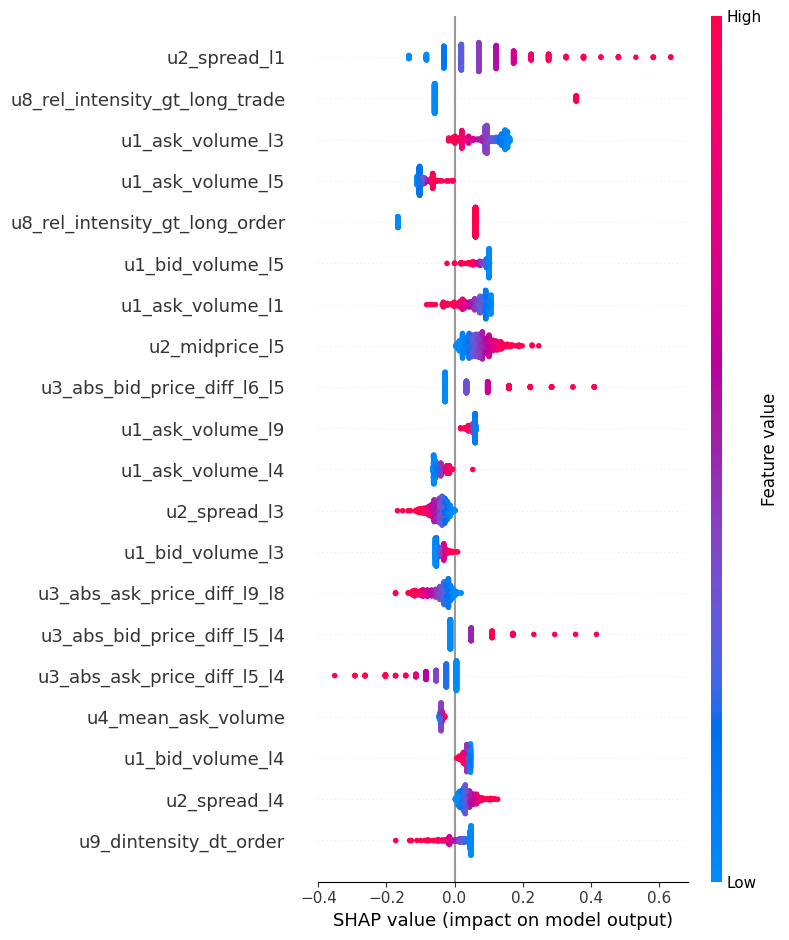

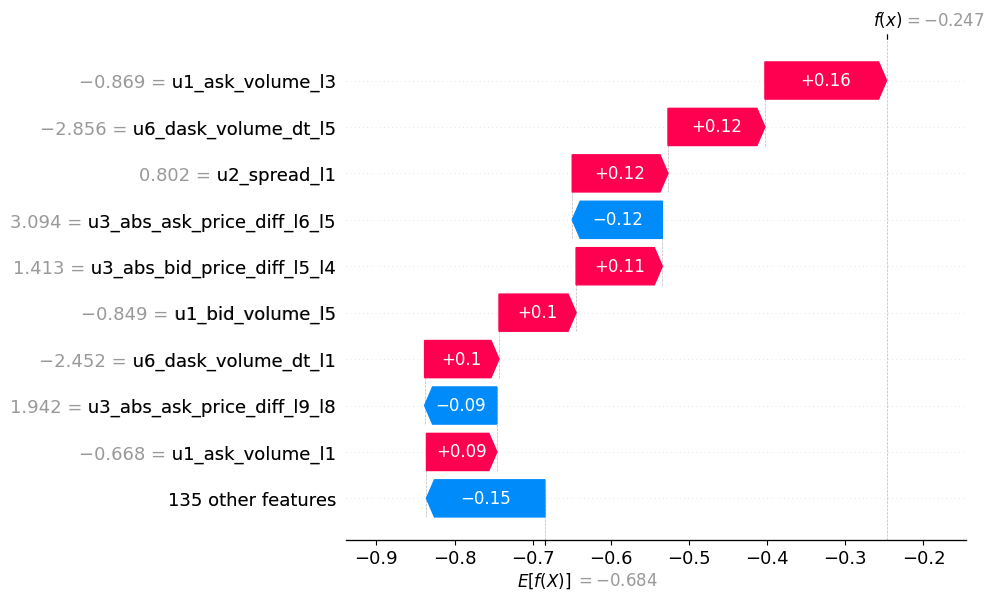

In [14]:
# pip install shap
import shap

# Linear explainer for multinomial logistic regression
X_background = X_train[: min(1000, len(X_train))]
X_explain = X_test[: min(500, len(X_test))]

explainer_shap = shap.LinearExplainer(
    (model.linear.weight.detach().cpu().numpy(),
     model.linear.bias.detach().cpu().numpy()),
    X_background,
    feature_names=FEATURE_COLS,
)

shap_values_raw = explainer_shap.shap_values(X_explain)

def to_classwise_shap_arrays(values, X_ref: np.ndarray) -> list[np.ndarray]:
    """Normalize SHAP outputs across versions to a list of (n_samples, n_features) arrays."""
    if isinstance(values, list):
        return values

    if not isinstance(values, np.ndarray):
        raise TypeError(f"Unsupported SHAP output type: {type(values)}")

    if values.ndim == 2:
        # Binary/single-output case
        return [values]

    if values.ndim != 3:
        raise ValueError(f"Unexpected SHAP output shape: {values.shape}")

    n_samples, n_features = X_ref.shape

    # Newer SHAP often returns (samples, features, classes).
    if values.shape[0] == n_samples and values.shape[1] == n_features:
        return [values[:, :, class_idx] for class_idx in range(values.shape[2])]

    # Older style can be (classes, samples, features).
    if values.shape[1] == n_samples and values.shape[2] == n_features:
        return [values[class_idx, :, :] for class_idx in range(values.shape[0])]

    raise ValueError(
        f"Could not align SHAP values shape {values.shape} with data shape {X_ref.shape}"
    )

shap_values_by_class = to_classwise_shap_arrays(shap_values_raw, X_explain)
target_class_idx = 2 if len(shap_values_by_class) > 2 else 0
shap_for_plot = shap_values_by_class[target_class_idx]

if shap_for_plot.shape != X_explain.shape:
    raise ValueError(
        f"SHAP/data mismatch after normalization: shap={shap_for_plot.shape}, data={X_explain.shape}"
    )

# Summary plot for "up" class (index 2 when available).
shap.summary_plot(shap_for_plot, X_explain, feature_names=FEATURE_COLS)

# Waterfall plot for a single prediction
sample_idx = min(42, X_explain.shape[0] - 1)
expected_value = np.asarray(explainer_shap.expected_value).reshape(-1)
base_value = expected_value[target_class_idx] if expected_value.size > 1 else float(expected_value[0])

shap.plots.waterfall(shap.Explanation(
    values=shap_for_plot[sample_idx],
    base_values=base_value,
    data=X_explain[sample_idx],
    feature_names=FEATURE_COLS,
))

# 9) Train More Sophisticated Model (Deep Neural Net)

This section trains a standard multi-layer perceptron (MLP) on the same 3-class target as the logistic regression baseline. The goal is to improve accuracy while keeping the model simple and interpretable. We fix random seeds for repeatability, add regularization (batch norm + dropout), and use early stopping plus learning-rate scheduling.

Note: The accuracy target is aspirational; the cell reports the best achieved metrics on this split.


=== MLP config 1/2: MLPConfig(input_dim=144, num_classes=3, hidden_dims=(512, 256, 128), dropout=0.35, lr=0.001, weight_decay=0.0001, batch_size=2048, max_epochs=50, patience=10) ===
Epoch 01 | train_loss=1.0547 | val_loss=1.0252 | val_acc=0.5248 | lr=1.00e-03
Epoch 02 | train_loss=1.0250 | val_loss=1.0124 | val_acc=0.5232 | lr=1.00e-03
Epoch 03 | train_loss=1.0144 | val_loss=1.0073 | val_acc=0.5275 | lr=1.00e-03
Epoch 04 | train_loss=1.0078 | val_loss=1.0011 | val_acc=0.5242 | lr=1.00e-03
Epoch 05 | train_loss=1.0036 | val_loss=0.9988 | val_acc=0.5368 | lr=1.00e-03
Epoch 06 | train_loss=0.9997 | val_loss=0.9988 | val_acc=0.5358 | lr=1.00e-03
Epoch 07 | train_loss=0.9966 | val_loss=0.9949 | val_acc=0.5349 | lr=1.00e-03
Epoch 08 | train_loss=0.9941 | val_loss=0.9964 | val_acc=0.5322 | lr=1.00e-03
Epoch 09 | train_loss=0.9917 | val_loss=0.9909 | val_acc=0.5302 | lr=5.00e-04
Epoch 10 | train_loss=0.9856 | val_loss=0.9885 | val_acc=0.5478 | lr=5.00e-04
Epoch 11 | train_loss=0.9841 | val_l

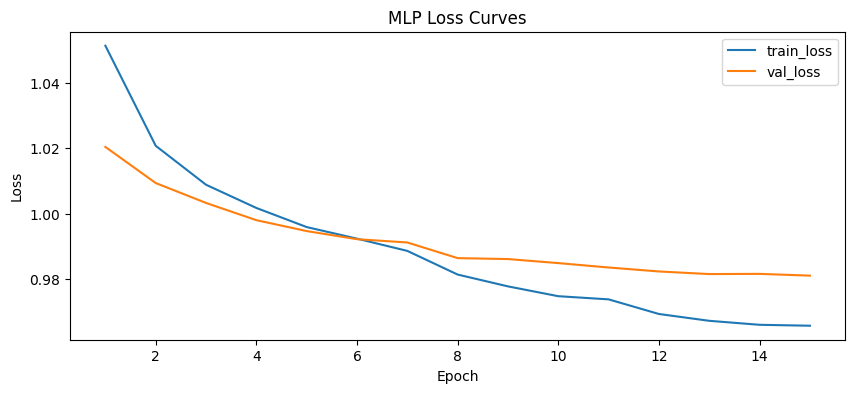

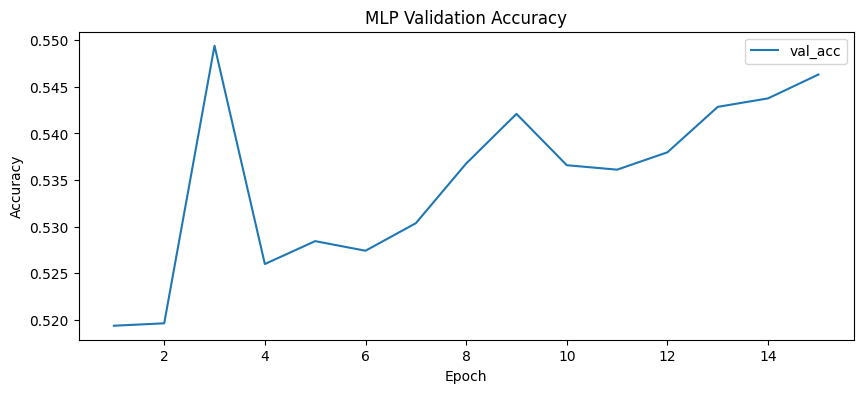


MLP classification report (test):


,precision,recall,f1-score,support
0,0.295999,0.350676,0.321026,21162.000000
1,0.816621,0.675305,0.739270,98394.000000
2,0.271688,0.451871,0.339345,19780.000000
accuracy,0.594283,0.594283,0.594283,0.594283
macro avg,0.461436,0.492617,0.466547,139336.000000
weighted avg,0.660192,0.594283,0.618976,139336.000000


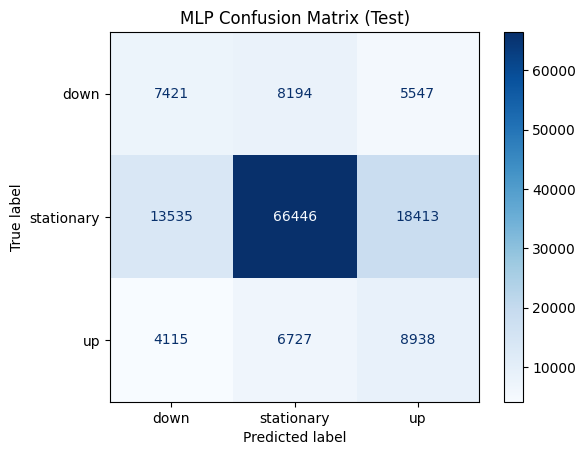

In [13]:
import random
from dataclasses import dataclass
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


@dataclass
class MLPConfig:
    input_dim: int
    num_classes: int
    hidden_dims: tuple[int, ...]
    dropout: float
    lr: float
    weight_decay: float
    batch_size: int
    max_epochs: int
    patience: int


mlp_configs = [
    MLPConfig(
        input_dim=len(FEATURE_COLS),
        num_classes=3,
        hidden_dims=(512, 256, 128),
        dropout=0.35,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=2048,
        max_epochs=50,
        patience=10,
    ),
    MLPConfig(
        input_dim=len(FEATURE_COLS),
        num_classes=3,
        hidden_dims=(768, 384, 192),
        dropout=0.25,
        lr=5e-4,
        weight_decay=1e-4,
        batch_size=2048,
        max_epochs=60,
        patience=12,
    ),
]


class MLPClassifier(nn.Module):
    def __init__(self, config: MLPConfig) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = config.input_dim

        for hidden_dim in config.hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.GELU(),
                    nn.Dropout(config.dropout),
                ]
            )
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, config.num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.net(features)


class_counts = np.bincount(y_train, minlength=3)
class_weights = (class_counts.sum() / (3 * class_counts)).astype(np.float32)
class_weights_tensor = torch.tensor(class_weights, device=device)


def build_mlp_loaders(config: MLPConfig) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_loader_mlp = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin_memory,
    )
    val_loader_mlp = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    test_loader_mlp = DataLoader(
        TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    return train_loader_mlp, val_loader_mlp, test_loader_mlp


def evaluate_loss(model: nn.Module, data_loader: DataLoader, criterion: nn.Module) -> float:
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            total_loss += loss.item() * batch_y.size(0)
            total_samples += batch_y.size(0)
    return total_loss / max(total_samples, 1)


def train_mlp_model(config: MLPConfig) -> dict:
    train_loader_mlp, val_loader_mlp, test_loader_mlp = build_mlp_loaders(config)

    model_mlp = MLPClassifier(config).to(device)
    criterion_mlp = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer_mlp = torch.optim.AdamW(
        model_mlp.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay,
    )
    scheduler_mlp = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_mlp,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    )

    best_state = None
    best_val_acc = -1.0
    best_epoch = 0
    history = []
    no_improve = 0

    for epoch in range(1, config.max_epochs + 1):
        model_mlp.train()
        epoch_loss = 0.0
        total_samples = 0

        for batch_x, batch_y in train_loader_mlp:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            optimizer_mlp.zero_grad(set_to_none=True)
            logits = model_mlp(batch_x)
            loss = criterion_mlp(logits, batch_y)
            loss.backward()
            optimizer_mlp.step()

            epoch_loss += loss.item() * batch_y.size(0)
            total_samples += batch_y.size(0)

        train_loss = epoch_loss / max(total_samples, 1)
        val_acc = evaluate_accuracy(model_mlp, val_loader_mlp)
        val_loss = evaluate_loss(model_mlp, val_loader_mlp, criterion_mlp)
        scheduler_mlp.step(val_acc)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr": optimizer_mlp.param_groups[0]["lr"],
            }
        )

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model_mlp.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={optimizer_mlp.param_groups[0]['lr']:.2e}"
        )

        if no_improve >= config.patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model_mlp.load_state_dict(best_state)

    val_acc = evaluate_accuracy(model_mlp, val_loader_mlp)
    test_acc = evaluate_accuracy(model_mlp, test_loader_mlp)

    return {
        "model": model_mlp,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "config": config,
        "loaders": (train_loader_mlp, val_loader_mlp, test_loader_mlp),
    }


best_mlp = None
start = time.perf_counter()
for idx, cfg in enumerate(mlp_configs, start=1):
    print(f"\n=== MLP config {idx}/{len(mlp_configs)}: {cfg} ===")
    result = train_mlp_model(cfg)
    if best_mlp is None or result["best_val_acc"] > best_mlp["best_val_acc"]:
        best_mlp = result

mlp_seconds = time.perf_counter() - start

model_mlp = best_mlp["model"]
mlp_training = best_mlp
mlp_val_acc = best_mlp["val_acc"]
mlp_test_acc = best_mlp["test_acc"]
train_loader_mlp, val_loader_mlp, test_loader_mlp = best_mlp["loaders"]

print("\nBest MLP config:", best_mlp["config"])
print("MLP best validation accuracy:", f"{best_mlp['best_val_acc']:.4f}")
print("MLP validation accuracy (best checkpoint):", f"{mlp_val_acc:.4f}")
print("MLP test accuracy:", f"{mlp_test_acc:.4f}")
print("MLP training time (seconds):", f"{mlp_seconds:.1f}")

# Training curves
history_df = pd.DataFrame(best_mlp["history"])
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Validation Accuracy")
plt.legend()
plt.show()

# Per-class metrics
model_mlp.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader_mlp:
        batch_x = batch_x.to(device, non_blocking=True)
        logits = model_mlp(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(batch_y.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

report = classification_report(all_true, all_preds, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
print("\nMLP classification report (test):")
display(report_df)

cm = confusion_matrix(all_true, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["down", "stationary", "up"]).plot(cmap="Blues", values_format="d")
plt.title("MLP Confusion Matrix (Test)")
plt.show()

# 10) Interpretability for the MLP

This section applies three gradient and perturbation-based interpretability techniques to the trained MLP. We use Captum (PyTorch interpretability library) because it provides consistent APIs across methods.

**Techniques**
- **Perturbation-based forward propagation (Feature Ablation):** Each feature is replaced with a baseline value, and the change in the model score is measured. This estimates how much the prediction depends on each feature.
- **Saliency maps:** Compute the gradient of the target class logit with respect to the input. Larger magnitudes indicate stronger local sensitivity.
- **Integrated Gradients:** A path-integral of gradients from a baseline input to the actual input. This is more stable than raw gradients and satisfies completeness (attributions sum to the output difference).

In [15]:
# Captum install failed on this environment, so we fallback to manual implementations.
try:
    from captum.attr import FeatureAblation, IntegratedGradients, Saliency
    captum_available = True
except Exception as exc:
    print("Captum not available, using manual attributions.")
    print("Reason:", exc)
    captum_available = False

model_mlp.eval()

# Select a sample to explain
sample_idx = 42
input_tensor = torch.tensor(X_test[sample_idx : sample_idx + 1], dtype=torch.float32).to(device)

with torch.no_grad():
    logits = model_mlp(input_tensor)
    probs = torch.softmax(logits, dim=1)
    target_class = int(torch.argmax(probs, dim=1).item())

baseline = torch.tensor(X_train.mean(axis=0, keepdims=True), dtype=torch.float32).to(device)


def summarize_attributions(attributions: torch.Tensor, feature_names: list[str], top_k: int = 15) -> pd.DataFrame:
    scores = attributions.detach().abs().cpu().numpy().reshape(-1)
    ranking = np.argsort(scores)[::-1][:top_k]
    return pd.DataFrame(
        {
            "feature": [feature_names[i] for i in ranking],
            "importance": scores[ranking],
        }
    )


def manual_feature_ablation(model: nn.Module, x: torch.Tensor, baseline_vec: torch.Tensor, target: int) -> torch.Tensor:
    model.eval()
    x_rep = x.repeat(x.shape[1], 1)
    x_ablated = x_rep.clone()
    for i in range(x.shape[1]):
        x_ablated[i, i] = baseline_vec[0, i]

    with torch.no_grad():
        base_probs = torch.softmax(model(x), dim=1)
        ablated_probs = torch.softmax(model(x_ablated), dim=1)

    delta = base_probs[:, target].repeat(x.shape[1]) - ablated_probs[:, target]
    return delta.reshape(1, -1)


def manual_saliency(model: nn.Module, x: torch.Tensor, target: int) -> torch.Tensor:
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    logits = model(x)
    score = logits[:, target].sum()
    score.backward()
    return x.grad


def manual_integrated_gradients(
    model: nn.Module,
    x: torch.Tensor,
    baseline_vec: torch.Tensor,
    target: int,
    steps: int = 128,
) -> torch.Tensor:
    model.eval()
    scaled_inputs = [baseline_vec + (float(i) / steps) * (x - baseline_vec) for i in range(steps + 1)]
    grads = []
    for scaled in scaled_inputs:
        scaled = scaled.clone().detach().requires_grad_(True)
        logits = model(scaled)
        score = logits[:, target].sum()
        score.backward()
        grads.append(scaled.grad)
    avg_grads = torch.stack(grads[:-1]).mean(dim=0)
    return (x - baseline_vec) * avg_grads


if captum_available:
    # 1) Perturbation-based forward propagation (Feature Ablation)
    fa = FeatureAblation(model_mlp)
    fa_attr = fa.attribute(input_tensor, baselines=baseline, target=target_class)

    # 2) Saliency maps (raw gradients)
    saliency = Saliency(model_mlp)
    sal_attr = saliency.attribute(input_tensor, target=target_class)

    # 3) Integrated Gradients
    ig = IntegratedGradients(model_mlp)
    ig_attr = ig.attribute(input_tensor, baselines=baseline, target=target_class, n_steps=128)
else:
    fa_attr = manual_feature_ablation(model_mlp, input_tensor, baseline, target_class)
    sal_attr = manual_saliency(model_mlp, input_tensor, target_class)
    ig_attr = manual_integrated_gradients(model_mlp, input_tensor, baseline, target_class, steps=128)

fa_top = summarize_attributions(fa_attr, FEATURE_COLS)
sal_top = summarize_attributions(sal_attr, FEATURE_COLS)
ig_top = summarize_attributions(ig_attr, FEATURE_COLS)

print("Target class:", target_class)
print("Predicted class probabilities:", probs.detach().cpu().numpy().round(4))

print("\nTop features by Feature Ablation:")
display(fa_top)

print("\nTop features by Saliency:")
display(sal_top)

print("\nTop features by Integrated Gradients:")
display(ig_top)

Captum not available, using manual attributions.
Reason: No module named 'captum'
Target class: 0
Predicted class probabilities: [[0.5241 0.0707 0.4052]]

Top features by Feature Ablation:


,feature,importance
0,u6_dask_volume_dt_l1,0.073718
1,u3_abs_bid_price_diff_l5_l4,0.035141
2,u3_abs_ask_price_diff_l9_l8,0.026653
3,u3_abs_ask_price_diff_l4_l3,0.025533
4,u3_abs_ask_price_diff_l8_l7,0.022675
5,u2_spread_l1,0.021101
6,u6_dask_volume_dt_l5,0.017467
7,u6_dask_volume_dt_l3,0.017421
8,u1_ask_volume_l3,0.017175
9,u6_dbid_volume_dt_l1,0.016978



Top features by Saliency:


,feature,importance
0,u6_dask_volume_dt_l1,0.117170
1,u1_bid_volume_l1,0.116757
2,u6_dbid_volume_dt_l1,0.096818
3,u2_spread_l1,0.079423
4,u3_abs_ask_price_diff_l10_l9,0.072477
5,u1_bid_volume_l6,0.065217
6,u8_rel_intensity_gt_long_order,0.058776
7,u9_dintensity_dt_trade,0.053789
8,u8_rel_intensity_gt_long_trade,0.053671
9,u1_ask_volume_l5,0.051267



Top features by Integrated Gradients:


,feature,importance
0,u6_dask_volume_dt_l1,0.223112
1,u3_abs_ask_price_diff_l6_l5,0.132468
2,u3_abs_bid_price_diff_l5_l4,0.092182
3,u1_ask_volume_l3,0.083360
4,u1_bid_volume_l1,0.074878
5,u6_dask_volume_dt_l5,0.072710
6,u3_abs_ask_price_diff_l4_l3,0.068837
7,u2_spread_l1,0.064013
8,u6_dbid_volume_dt_l1,0.062865
9,u3_abs_ask_price_diff_l8_l7,0.060439


# 11) Optimum Model Architecture

**Literature-backed choice:** A DeepLOB-style architecture (CNN + LSTM/TCN) is one of the most widely cited and empirically strong models for LOB mid-price movement prediction. It combines:
- **Convolutions** to extract local spatial patterns across LOB features.
- **Sequence modeling (LSTM or TCN)** to capture temporal dependencies over a sliding window of recent events.

We implement a simplified DeepLOB-like model using 1D temporal convolutions followed by an LSTM head. This adapts cleanly to the 144-feature representation in this dataset.

**Planned hyperparameters (initial run)**
- Sequence length: 100 events
- Conv1D blocks: 2 layers, 64 channels, kernel size 5, batch norm, ReLU, dropout 0.2
- LSTM: 1 layer, hidden size 64, dropout 0.2
- Optimizer: AdamW, lr = 1e-3, weight_decay = 1e-4
- Batch size: 256
- Early stopping: patience 8 on validation accuracy

**How to tune after the first run**
- If underfitting: increase channels (64 -> 128), LSTM hidden size (64 -> 128), or sequence length (100 -> 200).
- If overfitting: increase dropout (0.2 -> 0.4), add weight decay, or reduce model size.
- If training is unstable: lower learning rate (1e-3 -> 3e-4) or use gradient clipping (e.g., 1.0).
- If class imbalance dominates: adjust class weights or use focal loss.

In [ ]:
from dataclasses import dataclass


@dataclass
class SeqConfig:
    seq_len: int
    conv_channels: int
    lstm_hidden: int
    dropout: float
    lr: float
    weight_decay: float
    batch_size: int
    max_epochs: int
    patience: int


seq_configs = [
    SeqConfig(seq_len=100, conv_channels=64, lstm_hidden=64, dropout=0.2, lr=1e-3, weight_decay=1e-4, batch_size=256, max_epochs=40, patience=8),
    SeqConfig(seq_len=150, conv_channels=96, lstm_hidden=96, dropout=0.25, lr=5e-4, weight_decay=1e-4, batch_size=256, max_epochs=50, patience=10),
]

SEQ_TARGET = "label_1"


def build_sequences(
    df_split: pd.DataFrame,
    seq_len: int,
    feature_cols: list[str],
    target_label: str,
) -> tuple[np.ndarray, np.ndarray]:
    sequences: list[np.ndarray] = []
    labels: list[int] = []

    for _, group in df_split.groupby("file_name", sort=False):
        features = group[feature_cols].to_numpy(dtype=np.float32)
        labels_raw = group[f"{target_label}_encoded"].to_numpy(dtype=np.int64)

        if features.shape[0] < seq_len:
            continue

        features_scaled = scaler.transform(features).astype(np.float32)
        for end_idx in range(seq_len - 1, features_scaled.shape[0]):
            window = features_scaled[end_idx - seq_len + 1 : end_idx + 1]
            sequences.append(window)
            labels.append(int(labels_raw[end_idx]))

    if not sequences:
        raise ValueError("No sequences created. Reduce seq_len or check data split sizes.")

    return np.stack(sequences), np.array(labels, dtype=np.int64)


class DeepLOBLike(nn.Module):
    def __init__(self, n_features: int, n_classes: int, config: SeqConfig) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, config.conv_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(config.conv_channels),
            nn.ReLU(),
            nn.Conv1d(config.conv_channels, config.conv_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(config.conv_channels),
            nn.ReLU(),
            nn.Dropout(config.dropout),
        )
        self.lstm = nn.LSTM(
            input_size=config.conv_channels,
            hidden_size=config.lstm_hidden,
            num_layers=1,
            batch_first=True,
            dropout=config.dropout,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(config.lstm_hidden, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, features, seq_len)
        x = self.conv(x)       # (batch, conv_channels, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, conv_channels)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.classifier(x)


def build_seq_loaders(config: SeqConfig) -> tuple[DataLoader, DataLoader, DataLoader, np.ndarray]:
    X_seq_train, y_seq_train = build_sequences(train_full, config.seq_len, FEATURE_COLS, SEQ_TARGET)
    X_seq_test, y_seq_test = build_sequences(test_full, config.seq_len, FEATURE_COLS, SEQ_TARGET)

    X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(
        X_seq_train,
        y_seq_train,
        test_size=0.2,
        random_state=42,
        stratify=y_seq_train,
    )

    train_loader_seq = DataLoader(
        TensorDataset(torch.from_numpy(X_seq_train), torch.from_numpy(y_seq_train)),
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin_memory,
    )
    val_loader_seq = DataLoader(
        TensorDataset(torch.from_numpy(X_seq_val), torch.from_numpy(y_seq_val)),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    test_loader_seq = DataLoader(
        TensorDataset(torch.from_numpy(X_seq_test), torch.from_numpy(y_seq_test)),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    return train_loader_seq, val_loader_seq, test_loader_seq, y_seq_train


def evaluate_seq_accuracy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            logits = model(batch_x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    return correct / max(total, 1)


def train_sequence_model(config: SeqConfig) -> dict:
    train_loader_seq, val_loader_seq, test_loader_seq, y_seq_train = build_seq_loaders(config)

    seq_class_counts = np.bincount(y_seq_train, minlength=3)
    seq_class_weights = (seq_class_counts.sum() / (3 * seq_class_counts)).astype(np.float32)
    seq_class_weights_tensor = torch.tensor(seq_class_weights, device=device)

    model_seq = DeepLOBLike(n_features=len(FEATURE_COLS), n_classes=3, config=config).to(device)
    criterion_seq = nn.CrossEntropyLoss(weight=seq_class_weights_tensor)
    optimizer_seq = torch.optim.AdamW(model_seq.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler_seq = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_seq,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    )

    best_state = None
    best_val_acc = -1.0
    no_improve = 0
    history = []

    for epoch in range(1, config.max_epochs + 1):
        model_seq.train()
        epoch_loss = 0.0
        total_samples = 0

        for batch_x, batch_y in train_loader_seq:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            optimizer_seq.zero_grad(set_to_none=True)
            logits = model_seq(batch_x)
            loss = criterion_seq(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model_seq.parameters(), max_norm=1.0)
            optimizer_seq.step()

            epoch_loss += loss.item() * batch_y.size(0)
            total_samples += batch_y.size(0)

        train_loss = epoch_loss / max(total_samples, 1)
        val_acc = evaluate_seq_accuracy(model_seq, val_loader_seq)
        scheduler_seq.step(val_acc)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc})

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | lr={optimizer_seq.param_groups[0]['lr']:.2e}"
        )

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model_seq.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= config.patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model_seq.load_state_dict(best_state)

    val_acc = evaluate_seq_accuracy(model_seq, val_loader_seq)
    test_acc = evaluate_seq_accuracy(model_seq, test_loader_seq)

    return {
        "model": model_seq,
        "history": history,
        "best_val_acc": best_val_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "config": config,
        "loaders": (train_loader_seq, val_loader_seq, test_loader_seq),
    }


best_seq = None
start = time.perf_counter()
for idx, cfg in enumerate(seq_configs, start=1):
    print(f"\n=== Sequence config {idx}/{len(seq_configs)}: {cfg} ===")
    result = train_sequence_model(cfg)
    if best_seq is None or result["best_val_acc"] > best_seq["best_val_acc"]:
        best_seq = result

seq_seconds = time.perf_counter() - start

model_seq = best_seq["model"]
seq_training = best_seq
seq_val_acc = best_seq["val_acc"]
seq_test_acc = best_seq["test_acc"]
train_loader_seq, val_loader_seq, test_loader_seq = best_seq["loaders"]

print("\nBest sequence config:", best_seq["config"])
print("Sequence model best validation accuracy:", f"{best_seq['best_val_acc']:.4f}")
print("Sequence model validation accuracy (best checkpoint):", f"{seq_val_acc:.4f}")
print("Sequence model test accuracy:", f"{seq_test_acc:.4f}")
print("Sequence model training time (seconds):", f"{seq_seconds:.1f}")

# Training curves
history_df = pd.DataFrame(best_seq["history"])
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sequence Model Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sequence Model Validation Accuracy")
plt.legend()
plt.show()

# Per-class metrics
model_seq.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader_seq:
        batch_x = batch_x.to(device, non_blocking=True)
        logits = model_seq(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(batch_y.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

report = classification_report(all_true, all_preds, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
print("\nSequence model classification report (test):")
display(report_df)

cm = confusion_matrix(all_true, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["down", "stationary", "up"]).plot(cmap="Blues", values_format="d")
plt.title("Sequence Model Confusion Matrix (Test)")
plt.show()


=== Sequence config 1/2: SeqConfig(seq_len=100, conv_channels=64, lstm_hidden=64, dropout=0.2, lr=0.001, weight_decay=0.0001, batch_size=256, max_epochs=40, patience=8) ===


c:\Users\prane\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 01 | train_loss=0.8285 | val_acc=0.7000 | lr=1.00e-03
Epoch 02 | train_loss=0.7164 | val_acc=0.7586 | lr=1.00e-03
Epoch 03 | train_loss=0.6190 | val_acc=0.7749 | lr=1.00e-03
Epoch 04 | train_loss=0.5742 | val_acc=0.7948 | lr=1.00e-03
Epoch 05 | train_loss=0.5535 | val_acc=0.7914 | lr=1.00e-03
Epoch 06 | train_loss=0.5382 | val_acc=0.7930 | lr=1.00e-03
Epoch 07 | train_loss=0.5244 | val_acc=0.7932 | lr=1.00e-03
Epoch 08 | train_loss=0.5136 | val_acc=0.8011 | lr=1.00e-03
Epoch 09 | train_loss=0.5030 | val_acc=0.7974 | lr=1.00e-03
Epoch 10 | train_loss=0.4941 | val_acc=0.8013 | lr=1.00e-03
Epoch 11 | train_loss=0.4867 | val_acc=0.7994 | lr=1.00e-03
Epoch 12 | train_loss=0.4793 | val_acc=0.8040 | lr=1.00e-03
